# Data Cleaning and 2-Column Extraction

## Training data

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
import os

# Setup NLP tools
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

INPUT_PATH = r"C:\FindWork\NIQ\Junior-ML-Exercise\Case study\product-classification\data\Ori_Training_data.csv"
OUTPUT_PATH = r"C:\FindWork\NIQ\Junior-ML-Exercise\Case study\product-classification\data\Training_data.csv"

def load_fix_and_filter_data(input_path, output_path):
    fixed_rows = []
    
    # 1. Define the ONLY valid categories we want to keep
    valid_categories = [
        'Dry Goods & Pantry Staples',
        'Fresh & Perishable Items',
        'Household & Personal Care',
        'Beverages',
        'Specialty & Miscellaneous'
    ]
    
    print(f"Reading and repairing file: {input_path}")
    
    with open(input_path, 'r', encoding='utf-8', errors='ignore') as f:
        header = f.readline() 
        
        for line in f:
            parts = [p.strip() for p in line.split(',')]
            category = None
            category_index = -1
            
            # Find the Anchor (semicolon)
            for i, part in enumerate(parts):
                if ';' in part:
                    # Remove quotes and semicolons immediately
                    category = part.replace(';', '').replace('"', '').strip()
                    category_index = i
                    break
            
            if category and category_index > 0:
                description = " ".join(parts[:category_index]).strip()
            else:
                non_empty = [p for p in parts if p]
                if len(non_empty) >= 2:
                    category = non_empty[-1].replace(';', '').replace('"', '').strip()
                    description = " ".join(non_empty[:-1]).strip()
                else:
                    continue 

            description = description.replace('"', '')
            
            # 2. FILTER: Only keep rows where the category is one of our 5 real labels
            # This deletes the "Cocoa Krispies" noise row
            if category in valid_categories:
                fixed_rows.append({
                    'product_description': description,
                    'product_category': category
                })

    # Create the strict 2-column DataFrame
    df = pd.DataFrame(fixed_rows)
    
    # Save to CSV
    df.to_csv(output_path, index=False)
    print(f"SUCCESS: Cleaned file saved to {output_path}")
    print(f"Total clean records: {len(df)}")
    return df

def preprocess_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [w for w in text.split() if w not in stop_words]
    return ' '.join(words)

train_df = load_fix_and_filter_data(INPUT_PATH, OUTPUT_PATH)

# Add the ML-ready column
train_df['cleaned_description'] = train_df['product_description'].apply(preprocess_text)

# Preview
print("\n--- Final Cleaned Data Sample (2 Columns) ---")
print(train_df[['product_description', 'product_category']].head(10))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\B760M\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Reading and repairing file: C:\FindWork\NIQ\Junior-ML-Exercise\Case study\product-classification\data\Ori_Training_data.csv
SUCCESS: Cleaned file saved to C:\FindWork\NIQ\Junior-ML-Exercise\Case study\product-classification\data\Training_data.csv
Total clean records: 44999

--- Final Cleaned Data Sample (2 Columns) ---
                                 product_description  \
0           cookies cakes Chocolate Sandwich Cookies   
1                 spices seasonings All-Seasons Salt   
2               Robust Golden Unsweetened Oolong Tea   
3  frozen meals Smart Ones Classic Favorites Mini...   
4  marinades meat preparation Green Chile Anytime...   
5                                       Dry Nose Oil   
6       juice nectars Pure Coconut Water With Orange   
7   frozen produce Cut Russet Potatoes Steam N' Mash   
8           yogurt Light Strawberry Blueberry Yogurt   
9     Sparkling Orange Juice & Prickly Pear Beverage   

             product_category  
0  Dry Goods & Pantry Staples 

In [20]:
import pandas as pd

def split_and_clean_data(input_path):
    valid_classes = [
        "Beverages", "Dry Goods & Pantry Staples", "Fresh & Perishable Items",
        "Household & Personal Care", "Specialty & Miscellaneous"
    ]
    
    validation_rows = []
    query_rows = []
    
    with open(input_path, 'r', encoding='utf-8', errors='ignore') as f:
        header = f.readline()
        
        for line in f:
            parts = [p.strip() for p in line.split(',')]
            description = parts[0].replace('"', '').strip()
            
            # Look for human label
            found_label = None
            for part in parts:
                clean_part = part.replace('"', '').replace(';', '').strip()
                if clean_part in valid_classes:
                    found_label = clean_part
                    break
            
            # Split logic based on whether a label exists
            if found_label:
                validation_rows.append({
                    'product_description': description,
                    'human_label': found_label
                })
            else:
                query_rows.append({
                    'product_description': description
                })

    # Save clean validation file (Exactly 2 columns)
    df_val = pd.DataFrame(validation_rows)
    df_val.to_csv('data/Cleaned_Validation.csv', index=False)
    
    # Save clean query file (Exactly 1 column)
    df_query = pd.DataFrame(query_rows)
    df_query.to_csv('data/Cleaned_Query.csv', index=False)
    
    print(f"Cleaned! {len(df_val)} validation rows and {len(df_query)} query rows saved.")

# RUN SPLITTER
split_and_clean_data(r"C:\FindWork\NIQ\Junior-ML-Exercise\Case study\product-classification\data\Query_and_Validation_data.csv")

Cleaned! 938 validation rows and 3750 query rows saved.


## Validation data

In [ ]:
import pandas as pd
import os

def split_validation_and_query(input_path, val_path, query_path):
    # 1. Define the 5 main classes
    valid_classes = [
        "Beverages",
        "Dry Goods & Pantry Staples",
        "Fresh & Perishable Items",
        "Household & Personal Care",
        "Specialty & Miscellaneous"
    ]
    
    validation_data = []
    query_data = []
    
    print(f"Processing: {input_path}")
    
    with open(input_path, 'r', encoding='utf-8', errors='ignore') as f:
        header = f.readline() # Skip header
        
        for line in f:
            # Split by comma
            parts = [p.strip() for p in line.split(',')]
            if not parts or not parts[0]: 
                continue
            
            # ANCHOR LOGIC
            found_label = None
            label_index = -1
            
            # Check if any column contains one of the 5 valid classes
            for i, part in enumerate(parts):
                clean_part = part.replace('"', '').replace(';', '').strip()
                if clean_part in valid_classes:
                    found_label = clean_part
                    label_index = i
                    break
            
            # SPLITTING LOGIC
            if found_label:
                # 1. It belongs in VALIDATION
                # Merge everything before the label to fix comma-splits
                description = " ".join(parts[:label_index]).replace('"', '').strip()
                validation_data.append({
                    'product_description': description,
                    'human_label': found_label
                })
            else:
                # 2. It belongs in QUERY 
                # (This includes rows with no label OR labels like "Chocolate Truffle")
                # We take the first part as the product description and "remove" the messy label
                description = parts[0].replace('"', '').strip()
                query_data.append({
                    'product_description': description
                })

    # Create DataFrames
    df_val = pd.DataFrame(validation_data)
    df_query = pd.DataFrame(query_data)
    
    # Save to CSV
    df_val.to_csv(val_path, index=False)
    df_query.to_csv(query_path, index=False)
    
    print("-" * 30)
    print(f"SUCCESS!")
    print(f"Validation set (Strict 5 classes): {len(df_val)} rows saved to {val_path}")
    print(f"Query set (Unlabeled + Messy labels removed): {len(df_query)} rows saved to {query_path}")
    print("-" * 30)

# CONFIGURATION 
BASE_DIR = r"C:\FindWork\NIQ\Junior-ML-Exercise\Case study\product-classification\data"
INPUT = os.path.join(BASE_DIR, "Query_and_Validation_data.csv")
VAL_OUT = os.path.join(BASE_DIR, "Cleaned_Validation.csv")
QRY_OUT = os.path.join(BASE_DIR, "Cleaned_Query.csv")

# Run the split
split_validation_and_query(INPUT, VAL_OUT, QRY_OUT)

Processing: C:\FindWork\NIQ\Junior-ML-Exercise\Case study\product-classification\data\Query_and_Validation_data.csv
------------------------------
SUCCESS!
Validation set (Strict 5 classes): 938 rows saved to C:\FindWork\NIQ\Junior-ML-Exercise\Case study\product-classification\data\Cleaned_Validation.csv
Query set (Unlabeled + Messy labels removed): 3750 rows saved to C:\FindWork\NIQ\Junior-ML-Exercise\Case study\product-classification\data\Cleaned_Query.csv
------------------------------


## Class Distribution and Imbalance Check


--- Cleaned Class Distribution ---
                            Count  Percentage (%)
product_category                                 
Dry Goods & Pantry Staples  15146           33.66
Fresh & Perishable Items    11636           25.86
Household & Personal Care   10637           23.64
Beverages                    4926           10.95
Specialty & Miscellaneous    2654            5.90


C:\Users\B760M\AppData\Local\Temp\ipykernel_27048\118179544.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


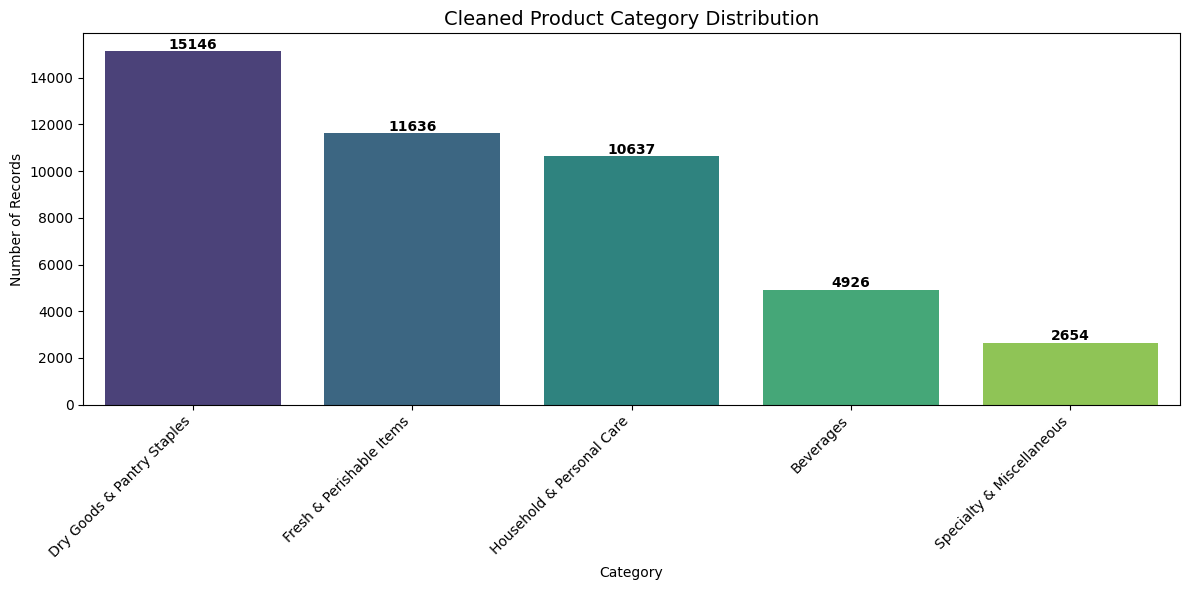

Imbalance Ratio: 5.71:1
Note: Moderate imbalance detected. Use 'stratify' when splitting data.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_distribution(df):
    print("\n--- Cleaned Class Distribution ---")
    counts = df['product_category'].value_counts()
    percentages = (df['product_category'].value_counts(normalize=True) * 100).round(2)
    
    dist_summary = pd.DataFrame({
        'Count': counts, 
        'Percentage (%)': percentages
    })
    print(dist_summary)
    
    # Visualization
    plt.figure(figsize=(12, 6))
    # Use a bar plot to check for imbalance
    sns.barplot(x=counts.index, y=counts.values, palette='viridis')
    
    plt.title('Cleaned Product Category Distribution', fontsize=14)
    plt.xlabel('Category')
    plt.ylabel('Number of Records')
    plt.xticks(rotation=45, ha='right')
    
    # Add count labels on top of bars
    for i, v in enumerate(counts.values):
        plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
        
    plt.tight_layout()
    plt.show()
    
    # Imbalance Conclusion
    ratio = counts.max() / counts.min()
    print(f"Imbalance Ratio: {ratio:.2f}:1")
    if ratio > 3:
        print("Note: Moderate imbalance detected. Use 'stratify' when splitting data.")

# RUN ANALYSIS
analyze_distribution(train_df)